In [1]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# --- 1. Chargement des données ---
# On récupère un jeu de données de référence pour prédire des valeurs continues (prix immobiliers)
housing = fetch_california_housing(as_frame=True)
X = housing.data  # Les variables explicatives (features)
y = housing.target  # La cible à prédire (target)

# --- 2. Découpage du dataset ---
# On sépare les données : 80% pour apprendre (train), 20% pour tester l'apprentissage (test)
# random_state=42 garantit que le mélange des données est reproductible à chaque exécution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- 3. Initialisation du modèle ---
# La régression linéaire cherche à tracer une droite (ou un plan) qui minimise l'erreur
model_beginner = LinearRegression()

# --- 4. Entraînement ---
# Le modèle analyse les données d'entraînement pour trouver les coefficients optimaux
model_beginner.fit(X_train, y_train)

# --- 5. Prédiction ---
# Le modèle fait des prédictions sur les données de test qu'il n'a jamais vues
y_pred = model_beginner.predict(X_test)

# --- 6. Évaluation des performances ---
# MAE : Erreur moyenne en valeur absolue (plus c'est bas, mieux c'est)
mae = mean_absolute_error(y_test, y_pred)
# R2 : Score de variance (1.0 est un score parfait)
r2 = r2_score(y_test, y_pred)

print(f"Erreur Moyenne Absolue (MAE) : {mae:.4f}")
print(f"Score R2 (précision globale) : {r2:.4f}")

Erreur Moyenne Absolue (MAE) : 0.5332
Score R2 (précision globale) : 0.5758


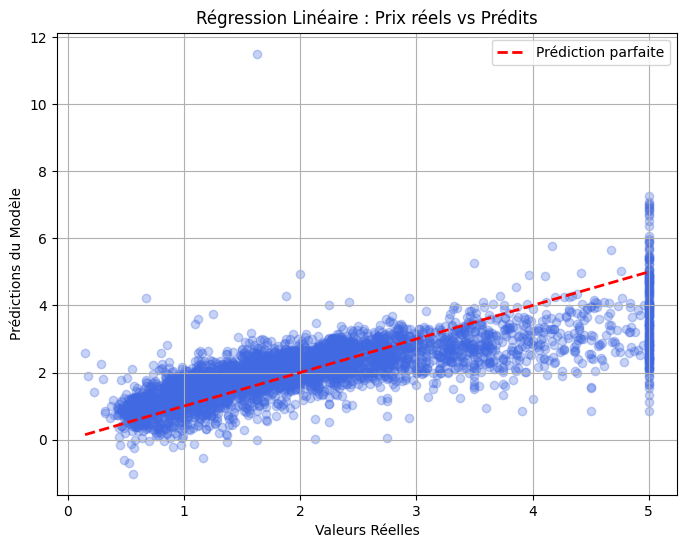

In [2]:
import matplotlib.pyplot as plt

# --- Visualisation : Valeurs réelles vs Prédictions ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color="royalblue")

# Ligne diagonale de référence (prédiction parfaite)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Prédiction parfaite",
)

plt.title("Régression Linéaire : Prix réels vs Prédits")
plt.xlabel("Valeurs Réelles")
plt.ylabel("Prédictions du Modèle")
plt.legend()
plt.grid(True)
plt.show()